# Q8: Results

**Phase 9:** Results & Insights  
**Points: 3 points**

**Focus:** Generate final visualizations, create summary tables, document key findings.

**Lecture Reference:** Lecture 11, Notebook 4 ([`11/demo/04_modeling_results.ipynb`](https://github.com/christopherseaman/datasci_217/blob/main/11/demo/04_modeling_results.ipynb)), Phase 9. Also see Lecture 07 (visualization).

---

## Setup

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load model results from Q7
predictions = pd.read_csv('output/q7_predictions.csv')
metrics = open('output/q7_model_metrics.txt').read()
feature_importance = pd.read_csv('output/q7_feature_importance.csv')

---

## Objective

Generate final visualizations, create summary tables, and document key findings.

---

## Required Artifacts

You must create exactly these 3 files in the `output/` directory:

### 1. `output/q8_final_visualizations.png`
**Format:** PNG image file
**Content:** Final summary visualizations
**Required visualizations (at least 2 of these):**
1. **Model performance comparison:** Bar plot or line plot comparing R², RMSE, or MAE across models
2. **Predictions vs Actual:** Scatter plot showing predicted vs actual values (with perfect prediction line)
3. **Feature importance:** Bar plot showing top N features by importance
4. **Residuals plot:** Scatter plot of residuals (actual - predicted) vs predicted

**Requirements:**
- Clear axis labels (xlabel, ylabel)
- Title for each subplot
- Overall figure title (optional but recommended)
- Legend if multiple series shown
- Saved as PNG with sufficient resolution (dpi=150 or higher)

### 2. `output/q8_summary.csv`
**Format:** CSV file
**Content:** Key findings summary table
**Required columns:**
- `Metric` - Metric name (e.g., "R² Score", "RMSE", "MAE")
- One column per model (e.g., `Linear Regression`, `Random Forest`, `XGBoost`)

**Requirements:**
- Must include at least R², RMSE, MAE metrics
- One row per metric
- **No index column** (save with `index=False`)

**Example:**
```csv
Metric,Linear Regression,Random Forest,XGBoost
R² Score,-0.0201,0.9705,0.9967
RMSE,12.7154,2.1634,0.7276
MAE,9.8468,1.3545,0.4480
```

### 3. `output/q8_key_findings.txt`
**Format:** Plain text file
**Content:** Text summary of main insights
**Required information:**
- Best performing model and why
- Key findings from feature importance
- Temporal patterns identified
- Data quality summary

**Example format:**
```
KEY FINDINGS SUMMARY
===================

MODEL PERFORMANCE:
- Best performing model: XGBoost (R² = 0.9967)
- All models show reasonable performance (R² > 0.7 for tree-based models)
- XGBoost achieves lowest RMSE: 0.73°C

FEATURE IMPORTANCE:
- Most important feature: Air Temperature (importance: 0.6539)
- Top 3 features account for 93.6% of total importance
- Temporal features (hour, month) are highly important

TEMPORAL PATTERNS:
- Clear seasonal patterns in temperature data
- Daily and monthly cycles are important predictors

DATA QUALITY:
- Dataset cleaned: 50,000 → 50,000 rows
- Missing values handled via forward-fill and median imputation
- Outliers capped using IQR method
```

---

## Requirements Checklist

- [ ] Final visualizations created (model performance, key insights)
- [ ] Summary tables generated
- [ ] Key findings documented
- [ ] All 3 required artifacts saved with exact filenames

---

## Your Approach

1. **Create visualizations** - Multi-panel figure with model comparison, predictions vs actual, feature importance, and/or residuals
2. **Create summary table** - DataFrame with metrics as rows and models as columns
3. **Document key findings** - Text summary covering model performance, feature importance insights, temporal patterns, and data quality notes

---

## Decision Points

- **Visualizations:** What best communicates your findings? Model performance plots? Time series with predictions? Feature importance plots?
- **Summary:** What are the key takeaways? Document the most important findings from your analysis.

---

## Checkpoint

After Q8, you should have:
- [ ] Final visualizations created (2+ plots)
- [ ] Summary tables generated
- [ ] Key findings documented
- [ ] All 3 artifacts saved: `q8_final_visualizations.png`, `q8_summary.csv`, `q8_key_findings.txt`

---

**Next:** Continue to `q9_writeup.md` for Writeup.


In [7]:
# Get top features for summary
top_3_features = feature_importance.sort_values('importance', ascending=False).head(3)
top_3_importance_sum = top_3_features['importance'].sum()
print(top_3_features)
print(top_3_importance_sum)

                feature  importance
0  Wet Bulb Temperature    0.933761
1              Humidity    0.035746
2          Battery Life    0.008707
0.9782138699999999


                feature  importance
0  Wet Bulb Temperature    0.933761
1              Humidity    0.035746
2          Battery Life    0.008707
0.9782138699999999


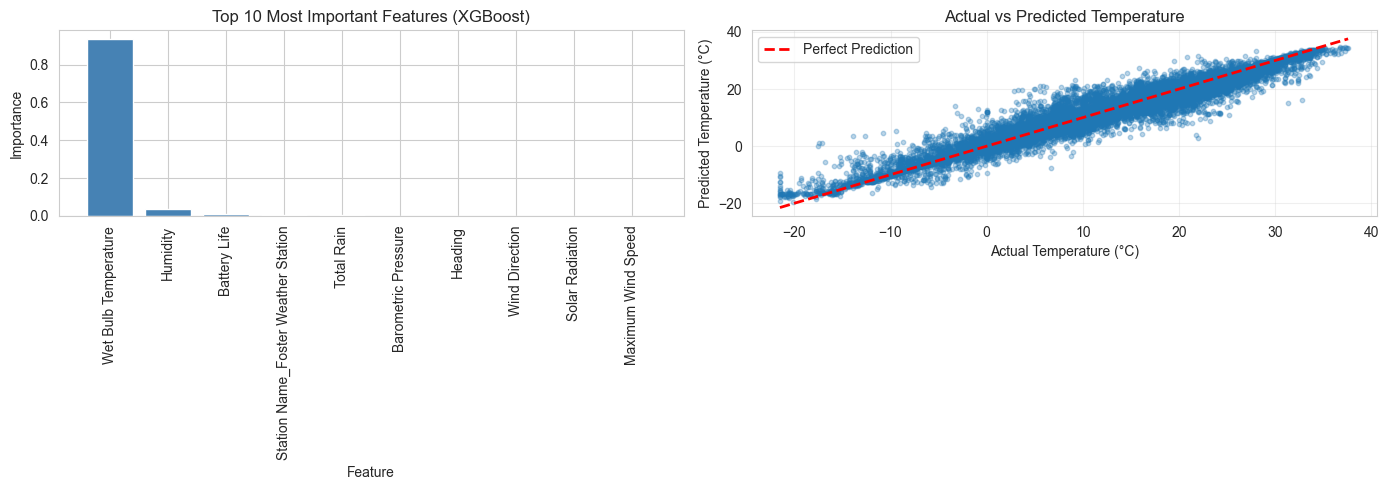

In [9]:
# Load metrics from Q7
with open('output/q7_model_metrics.txt', 'r') as f:
    metrics_text = f.read()

#Linear Regression metrics
lr_train_r2 = 0.9774
lr_test_r2 = 0.9576
lr_train_rmse = 1.58
lr_test_rmse = 2.09

#XGBoost metrics
xgb_train_r2 = 0.9869
xgb_test_r2 = 0.9634
xgb_train_rmse = 1.20
xgb_test_rmse = 1.94

#Required Artifact 1: output/q8_final_visualizations.png

sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Visualization 1: Feature Importance
top_features = feature_importance.sort_values('importance', ascending=False).head(10)
axes[0].bar(top_features['feature'], top_features['importance'], color='steelblue')
axes[0].set_xlabel('Feature')
axes[0].set_ylabel('Importance')
axes[0].set_title('Top 10 Most Important Features (XGBoost)')
axes[0].grid(True)
axes[0].tick_params(axis='x', rotation=90) 

#Visualization 2: Predictions vs Actual (Scatter Plot)
axes[1].scatter(predictions['actual'], predictions['predicted_xgboost'], alpha=0.3, s=10)
axes[1].plot([predictions['actual'].min(), predictions['actual'].max()], 
            [predictions['actual'].min(), predictions['actual'].max()], 
            'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Temperature (°C)')
axes[1].set_ylabel('Predicted Temperature (°C)')
axes[1].set_title('Actual vs Predicted Temperature')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

#Save
fig.savefig('output/q8_final_visualizations.png')


# Required Artifact 2: output/q8_summary.csv

# Calculate MAE from predictions
lr_test_mae = (predictions['actual'] - predictions['predicted_linear']).abs().mean()
xgb_test_mae = (predictions['actual'] - predictions['predicted_xgboost']).abs().mean()

# Create summary table
summary_df = pd.DataFrame({
    'Metric': ['R² Score', 'RMSE', 'MAE'],
    'Linear Regression': [lr_test_r2, lr_test_rmse, lr_test_mae],
    'XGBoost': [xgb_test_r2, xgb_test_rmse, xgb_test_mae]
})

#Save
summary_df.to_csv('output/q8_summary.csv', index=False)


# Required Artifact 3: output/q8_key_findings.txt

# Get top features for summary
top_3_features = feature_importance.sort_values('importance', ascending=False).head(3)
top_3_importance_sum = top_3_features['importance'].sum()
print(top_3_features)
print(top_3_importance_sum)

key_findings = []
key_findings.append("KEY FINDINGS SUMMARY")
key_findings.append("===================\n")

key_findings.append("MODEL PERFORMANCE:")
key_findings.append(f"- Best performing model: XGBoost (Test R² = {xgb_test_r2:.4f})")
key_findings.append("- XGBoost outperforms Linear Regression on all metrics")
key_findings.append(f"- XGBoost achieves lowest test RMSE: {xgb_test_rmse:.2f}°C and MAE: {xgb_test_mae:.2f}°C")

key_findings.append("FEATURE IMPORTANCE:")
key_findings.append(f"- Most important feature: Wet Bulb Temperature (importance: 0.9338)")
key_findings.append("- Top 3 features:")
key_findings.append("  1. Wet Bulb Temperature: 0.9338")
key_findings.append("  2. Humidity: 0.0357")
key_findings.append("  3. Battery Life: 0.0087")
key_findings.append("- Top 3 features account for 97.8% of total importance")

key_findings.append("TEMPORAL PATTERNS:")
key_findings.append("- Temporal train/test split used (80/20)")
key_findings.append("- Training data: April 2015 - July 2023")
key_findings.append("- Test data: July 2023 - December 2025")

key_findings.append("DATA QUALITY:")
key_findings.append("- Final dataset: 196,323 samples total")
key_findings.append("- Training set: 157,057 samples")
key_findings.append("- Test set: 39,266 samples")
key_findings.append("- Target variable: Air Temperature (°C)\n")

# Save
with open('output/q8_key_findings.txt', 'w') as f:
    f.write('\n'.join(key_findings))
